# Ex. 9.4

## a)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(seed=42)

In [2]:
df = pd.read_csv("../../Datasets_from_the_book/salmon.dat", sep="\s+", dtype=np.float64)
categories = df.columns.tolist()
data = df.to_numpy()

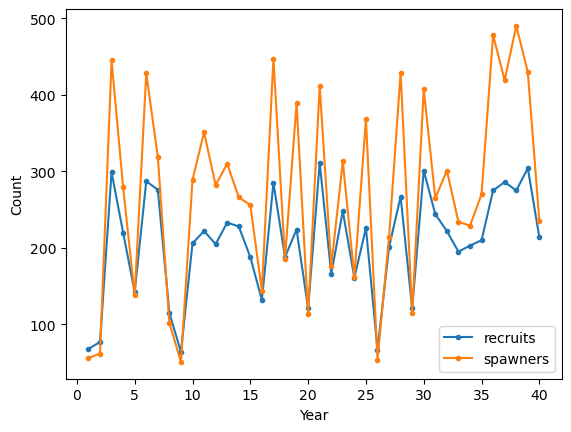

In [3]:
years = data[:,0]
R = data[:,1]
S = data[:,2]

plt.plot(years, R, ".-", label=categories[1])
plt.plot(years, S, ".-", label=categories[2])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

Given the **Beverton-Holt** model:
$$
R = \frac{1}{\beta_1 + \beta_2/S}
$$

we can use the transformed variables $R = 1/r$ and $S = 1/s$, and rewrite the expression:
$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2/\frac{1}{s}}
$$

$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2 s}
$$

$$
r = \beta_1 + \beta_2 s
$$

Now we can find the parameters with linear regression, having $r = 1/R$ and $s = 1/S$.

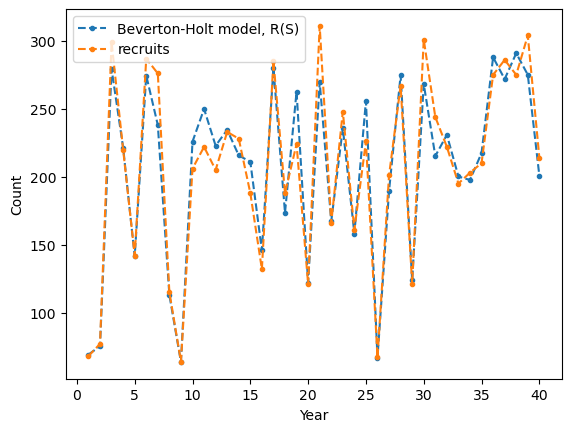

In [4]:
def beverton_holt_model(beta1, beta2, S):
    R = 1.0/(beta1 + (beta2/S))
    return R

r = 1/R
s = 1/S
r = r.reshape(-1,1)
s = s.reshape(-1,1)

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
beta2 = model.coef_.item()
beta1 = model.intercept_.item()

plt.plot(years, beverton_holt_model(beta1, beta2, S).ravel(), ".--", label="Beverton-Holt model, R(S)")
plt.plot(years, R, ".--", label=categories[1])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

If $R = S$, we have:
$$
R = \frac{1}{\beta_1 + \beta_2/R}
$$

$$
R(\beta_1 + \beta_2/R) = 1
$$

$$
R\beta_1 + \beta_2 = 1
$$

$$
R = S \rightarrow \widehat{R} = \frac{1 - \beta_2}{\beta_1}
$$

$\widehat{R}$ is then our point estimate for the stable population level.

In [5]:
def RS_opti_func(beta1, beta2): 
    return (1- beta2)/beta1

In [6]:
RS_opti_OLS = RS_opti_func(beta1, beta2)
print(RS_opti_OLS)
print(beverton_holt_model(beta1, beta2, RS_opti_OLS))

150.0976343009786
150.0976343009786


In [7]:
print(beta1)
print(beta2)

0.0020132306968982543
0.6978188350934615


### Bootstrapping residuals

In [8]:
n_bootstraps = 10000
n_samples_per_bootstrap = len(r)
bootstraps_res = np.zeros([n_bootstraps, n_samples_per_bootstrap])

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
predictions = model.predict(s)
residues = r - predictions

for i in range(n_bootstraps):
    bootstraps_res[i,:] = rng.choice(residues, size=len(residues.ravel()), replace=True).reshape(1,-1)

bootstraps_betas = np.zeros([n_bootstraps, 2])
Y = predictions.reshape(1,-1) + bootstraps_res

for i in range(n_bootstraps):
    new_model = LinearRegression(fit_intercept=True).fit(X=s, y=Y[i,:])
    bootstraps_betas[i,0] = new_model.intercept_.item()
    bootstraps_betas[i,1] = new_model.coef_.item()
    
bootstraped_beta1s = bootstraps_betas[:,0]
bootstraped_beta2s = bootstraps_betas[:,1]

res_confidence_interval95_beta1 = np.percentile(bootstraped_beta1s, [2.5, 97.5])
res_confidence_interval95_beta2 = np.percentile(bootstraped_beta2s, [2.5, 97.5])

print(f"95% confidence interval residuals bootstraps, beta1: {res_confidence_interval95_beta1}, and beta2: {res_confidence_interval95_beta2}")

cases_beta1_se = np.std(bootstraped_beta1s)
cases_beta2_se = np.std(bootstraped_beta2s)

print(f"Standard error of all residuals bootstraps, beta1: {cases_beta1_se:.3g}, and beta2: {cases_beta2_se:.3g}")

95% confidence interval residuals bootstraps, beta1: [0.00185885 0.00216995], and beta2: [0.67614196 0.72020116]
Standard error of all residuals bootstraps, beta1: 7.97e-05, and beta2: 0.0113


### Bootstrapping cases (pairs)

In [9]:
n_bootstraps = 10000
s_r_pairs = np.concatenate((s, r), axis=1)

# Don't need to store bootstrap array, only array of the betas

stored_betas = np.zeros([n_bootstraps, 2])

for i in range(n_bootstraps):
    bootstrap_pairs = rng.choice(s_r_pairs, size=n_samples_per_bootstrap, replace=True)
    bsample_s = bootstrap_pairs[:,0].reshape(-1,1)
    bsample_r = bootstrap_pairs[:,1].reshape(-1,1)
    model = LinearRegression(fit_intercept=True).fit(X=bsample_s, y=bsample_r)
    stored_betas[i,0] = model.intercept_.item()
    stored_betas[i,1] = model.coef_.item()
    
stored_beta1s = stored_betas[:,0]
stored_beta2s = stored_betas[:,1]

cases_confidence_interval95_beta1 = np.percentile(stored_beta1s, [2.5, 97.5])
cases_confidence_interval95_beta2 = np.percentile(stored_beta2s, [2.5, 97.5])

print(f"95% confidence interval beta1: {cases_confidence_interval95_beta1}")
print(f"95% confidence interval beta2: {cases_confidence_interval95_beta2}")

cases_beta1_se = np.std(stored_beta1s)
cases_beta2_se = np.std(stored_beta2s)

print(f"Standard error of all bootstraps, beta1: {cases_beta1_se:.3g}")
print(f"Standard error of all bootstraps, beta2: {cases_beta2_se:.3g}")





95% confidence interval beta1: [0.00185296 0.0021707 ]
95% confidence interval beta2: [0.68139189 0.71580926]
Standard error of all bootstraps, beta1: 8.06e-05
Standard error of all bootstraps, beta2: 0.00896


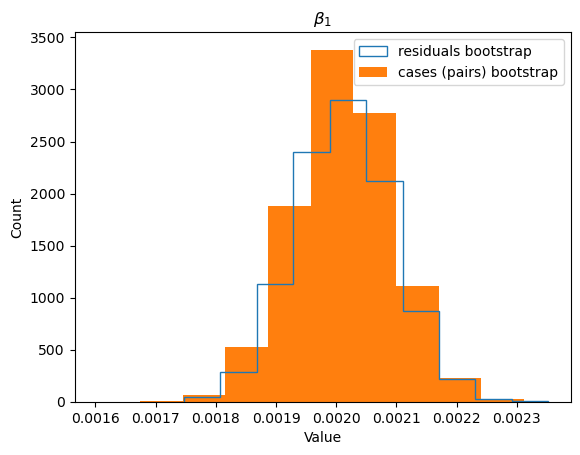

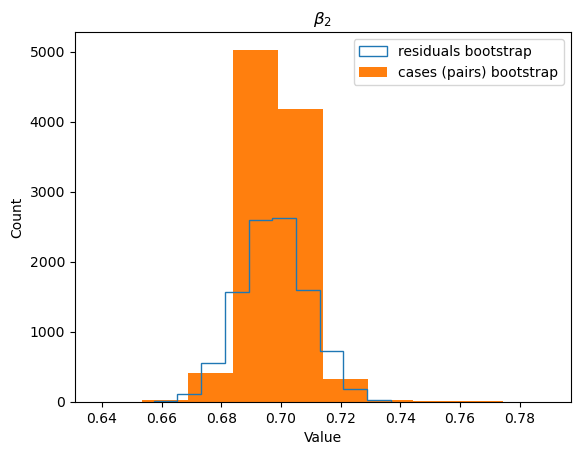

In [10]:
plt.hist(bootstraped_beta1s, histtype="step", label="residuals bootstrap", bins=10)
plt.hist(stored_beta1s, label="cases (pairs) bootstrap", bins=10)
plt.title(r"$\beta_1$")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.hist(bootstraped_beta2s, histtype="step", label="residuals bootstrap", bins=10)
plt.hist(stored_beta2s, label="cases (pairs) bootstrap", bins=10)
plt.title(r"$\beta_2$")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

We see that beta2 from the cases (pairs) bootstrap method have one order of magnitude smaller standard error compared to beta2 in the residuals bootstrap. Both of the original sample estimates for beta1 and beta2 are within the 95% confidence interval from both bootstrap methods.

In [23]:
se_res_bs = np.std(RS_opti_func(bootstraped_beta1s, bootstraped_beta2s))
se_pair_bs = np.std(RS_opti_func(stored_beta1s, stored_beta2s))
print(se_res_bs)
print(se_pair_bs)

ci95_res_bs = np.percentile(RS_opti_func(bootstraped_beta1s, bootstraped_beta2s), [2.5, 97.5])
ci95_pair_bs = np.percentile(RS_opti_func(stored_beta1s, stored_beta2s), [2.5, 97.5])
print(ci95_res_bs)
print(ci95_pair_bs)

4.0467265638205205
3.8045846888751393
[142.41713081 158.39623994]
[142.82547274 157.6614053 ]


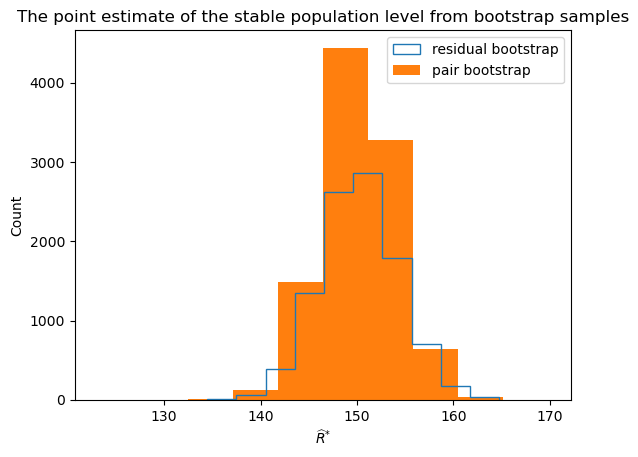

In [16]:
plt.hist(RS_opti_func(bootstraped_beta1s, bootstraped_beta2s), histtype="step", label="residual bootstrap")
plt.hist(RS_opti_func(stored_beta1s, stored_beta2s), label="pair bootstrap")
plt.title("The point estimate of the stable population level from bootstrap samples")
plt.xlabel(r"$\widehat{R}^{*}$")
plt.ylabel("Count")
plt.legend()
plt.show()

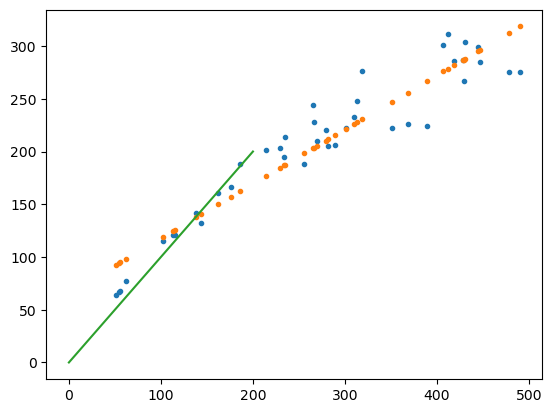

In [10]:
model_R_S = LinearRegression(fit_intercept=True).fit(X=S.reshape(-1,1), y=R.reshape(-1,1))
plt.plot(S,R,".")
plt.plot(S, model_R_S.predict(S.reshape(-1,1)), ".")
plt.plot([0, 200], [0, 200], "-")

## b)

If 

$$
R = S \rightarrow \widehat{R} = \frac{1 - \beta_2}{\beta_1}
$$

is our estimator, then we can bias correct it using the betas from the bootstrapping. Choosing the pair bootstrap data.

Because of Jensen's inequality it is better to take the mean of calculated $\widehat{R}$ instead of using the mean of the beta paramters.

In [24]:
print(np.mean(RS_opti_func(bootstraped_beta1s, bootstraped_beta2s)))
print(np.mean(RS_opti_func(stored_beta1s, stored_beta2s)))

150.20672293829554
150.15543245888776


In [27]:
mean_R_hat_res_bs = np.mean(RS_opti_func(bootstraped_beta1s, bootstraped_beta2s))
mean_R_hat_pair_bs = np.mean(RS_opti_func(stored_beta1s, stored_beta2s))

print("Original point estimate:", RS_opti_OLS)
print("Point estimate from residual bootstrap:", mean_R_hat_res_bs)
print("Point estimate from pair bootstrap:", mean_R_hat_pair_bs)

Original point estimate: 150.0976343009786
Point estimate from residual bootstrap: 150.20672293829554
Point estimate from pair bootstrap: 150.15543245888776


In [30]:
bias_res = mean_R_hat_res_bs - RS_opti_OLS
bias_pair = mean_R_hat_pair_bs - RS_opti_OLS
print("Bias residual bootstrap:", bias_res)
print("Bias pair bootstrap:", bias_pair)

Bias residual bootstrap: 0.10908863731694396
Bias pair bootstrap: 0.05779815790916132


In [31]:
corrected_point_estimate_RS_opti_res = RS_opti_OLS - bias_res
corrected_point_estimate_RS_opti_pair = RS_opti_OLS - bias_pair
print("Corrected point estimate, from res bs:", corrected_point_estimate_RS_opti_res)
print("Corrected point estimate, form pair bs:", corrected_point_estimate_RS_opti_pair)

Corrected point estimate, from res bs: 149.98854566366165
Corrected point estimate, form pair bs: 150.03983614306944
